# Replica of the scITD Analysis

The goal of this ntoebook is to replicate, on the breast-cancer data which is provided, the analysis which scITD conducts in order to gain insight on how tensor decompositions can be used to meaningfully analyse cell-cycle data.

## 0. Imports:

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly import tenalg

---

## 1. Data import and preprocessing:

### 1.1 Data import:

In [2]:
adata = sc.read_h5ad("../data/breast_cancer_zikry_wayne/T47D_merged.h5ad")

Removing any protein containing $``\texttt{pRB}''$ and $``\texttt{cyto}''$:

In [3]:
filter = [f for f in adata.var_names if ("pRB" not in f) and ("cyto" not in f)]
adata = adata[:, filter]

Understanding our data:

In [4]:
print(f'n_obs x n_vars: {adata.shape}')

n_obs x n_vars: (612372, 51)


In [5]:
print(f'cell barcodes (row index): {adata.obs_names}\n')
print(f'gene/feature names (column index): {adata.var_names}\n')

cell barcodes (row index): Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '144088', '144089', '144090', '144091', '144092', '144093', '144094',
       '144095', '144096', '144097'],
      dtype='object', length=612372)

gene/feature names (column index): Index(['nuclear_mean_ERa', 'nuclear_mean_Ki67', 'nuclear_mean_PR',
       'nuclear_area', 'nuclear_mean_DAPI', 'nuclear_mean_HES1',
       'nuclear_mean_p38', 'nuclear_mean_p16', 'nuclear_mean_PH3',
       'nuclear_mean_p65', 'nuclear_mean_pAKT', 'nuclear_mean_53BP1',
       'nuclear_mean_pS6', 'nuclear_mean_pERK', 'nuclear_mean_pATR',
       'nuclear_mean_ECad', 'nuclear_mean_AurB', 'nuclear_mean_pp130',
       'nuclear_mean_CDC25c', 'nuclear_mean_p130', 'nuclear_mean_pcdc2',
       'nuclear_mean_CDH1', 'nuclear_mean_NaKATPase', 'nuclear_mean_cycA2',
       'nuclear_mean_cycE1', 'nuclear_mean_CDK2', 'nuclear_mean_RB',
       'nuclear_mean_CycB1', 'nuclear_mean_p21', 'nuclear_mean_Plk1',
       'nuclear_mean

In [6]:
adata.obs

,core,binucleated,CellID,GMM_phase_labels,DNA_int_obs,nuclear_mean_cycA2_obs,Endocycle,drug_name
0,1.0,1,0,G0,4.514192,162.493695,Polyploid,Control
1,1.0,0,1,S,4.379941,2641.722167,Diploid,Control
2,1.0,0,2,G0,5.348979,159.590886,Polyploid,Control
3,1.0,0,3,G1,2.106505,181.602243,Diploid,Control
4,1.0,0,4,G0,1.826259,155.153846,Diploid,Control
...,...,...,...,...,...,...,...,...
144093,8.0,0,144093,G1,2.205912,240.395580,Diploid,Dinaciclib
144094,8.0,0,144094,G1,2.033355,193.921158,Diploid,Dinaciclib
144095,8.0,0,144095,G0,2.081168,531.183796,Diploid,Dinaciclib
144096,8.0,0,144096,G0,1.971715,174.206118,Diploid,Dinaciclib


In [7]:
total = adata.obs['drug_name'].value_counts().sum()
adata.obs['drug_name'].value_counts() / total

drug_name
Dinaciclib      0.235311
RO-3306         0.224222
Palbociclib     0.151197
Control         0.099938
CVT-313         0.095159
PF-3600         0.081302
Samuraciclib    0.062359
Talazoparib     0.050512
Name: count, dtype: float64

In [8]:
pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

,nuclear_mean_ERa,nuclear_mean_Ki67,nuclear_mean_PR,nuclear_area,nuclear_mean_DAPI,nuclear_mean_HES1,nuclear_mean_p38,nuclear_mean_p16,nuclear_mean_PH3,nuclear_mean_p65,...,nuclear_mean_cycB2,nuclear_mean_bCat,nuclear_mean_SKP2,nuclear_mean_E2F1,nuclear_mean_HER2,nuclear_mean_YAP1,nuclear_mean_CDT1,nuclear_mean_pCdc6,nuclear_mean_cycE2,DNA_int
0,754.789040,14205.797769,13824.470417,2062.0,5416.131911,1485.613967,3901.981571,2291.766731,600.428710,318.609602,...,416.629486,8345.069350,298.383608,206.741998,142.099418,382.927740,620.310378,3737.719205,1752.971387,4.514192
1,832.162028,41149.482604,12279.211730,2012.0,5385.651093,1413.356859,2275.119284,1807.549205,1148.586481,221.265408,...,1565.121272,3368.619781,737.187376,168.786779,112.441352,314.281809,224.231610,3619.837972,1534.753479,4.379941
2,328.425755,740.010241,9462.067844,3906.0,3387.946493,1368.803379,2021.209677,1756.368920,592.180748,196.302355,...,432.494112,4534.464158,145.008705,151.186636,114.547875,272.813108,153.129032,2678.011265,1318.167435,5.348979
3,779.162209,2284.339085,16241.853322,1159.0,4496.525453,1446.301122,2294.037101,1651.933563,424.948231,198.013805,...,473.125971,2676.482312,271.773080,193.512511,110.572045,301.002588,1175.510785,2667.613460,1387.455565,2.106505
4,164.739645,4044.065089,7437.127811,845.0,5346.917160,1468.494675,2283.326627,2620.850888,464.481657,234.164497,...,419.126627,3691.331361,172.768047,170.366864,110.169231,287.253254,172.396450,3125.405917,1676.265089,1.826259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144093,880.287293,5356.478453,16642.471823,905.0,7274.132597,1671.966851,2051.048619,2393.575691,589.051934,356.443094,...,455.776796,3903.870718,271.385635,203.760221,115.297238,374.544751,414.617680,3537.779006,1664.910497,2.205912
144094,500.495010,38115.935130,7232.517964,1002.0,6056.015968,1514.709581,2802.153693,1202.762475,1085.689621,312.506986,...,383.615768,3756.166667,846.182635,172.916168,113.771457,346.606786,369.161677,4808.057884,1413.252495,2.033355
144095,568.207052,5392.303076,19980.589647,1333.0,4659.276819,1513.505626,2106.498125,1236.012003,385.189047,268.472618,...,501.193548,3832.446362,233.273068,160.515379,113.798200,346.992498,186.757689,2629.363091,1493.633158,2.081168
144096,212.800941,1569.874353,8013.307765,2125.0,2769.024000,1652.708706,951.613647,1834.586824,359.054118,166.764706,...,337.503059,2932.562824,142.776471,142.712941,110.608000,314.088941,137.038588,2346.780235,1280.648000,1.971715


### 1.2 Preprocessing:

We exclude phases G0 and M from our data set:

In [9]:
condition_G0_M = (~adata.obs['GMM_phase_labels'].isin(['G0', 'M']))
adata = adata[condition_G0_M]

We subset to the following proteins:

In [10]:
features = [
    'nuclear_mean_Ki67', 'nuclear_area', 'nuclear_mean_p16', 
    'nuclear_mean_CDH1', 'nuclear_mean_cycA2', 'nuclear_mean_cycE1',
    'nuclear_mean_CDK2', 'nuclear_mean_RB', 'nuclear_mean_CycB1',
    'nuclear_mean_p21', 'nuclear_mean_cycD1', 'nuclear_mean_CDK6',
    'nuclear_mean_CDK4', 'nuclear_mean_cycA1', 'nuclear_mean_PCNA', 
    'nuclear_mean_p53', 'nuclear_mean_p27', 'nuclear_mean_cycB2', 
    'nuclear_mean_SKP2', 'nuclear_mean_CDT1', 'nuclear_mean_cycE2',
    'DNA_int'
]

adata = adata[:, features]

In [11]:
treatments = list(adata.obs["drug_name"].cat.categories)
phases = list(adata.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in adata.var_names]

In [12]:
import phate

# PHATE on sampled data
adata_sub = sc.pp.subsample(adata, n_obs=min(10000, adata.n_obs), copy=True, random_state=0)
phate_op = phate.PHATE()
data_phate = phate_op.fit_transform(adata_sub.X)
dominant_protein = adata_sub.to_df().idxmax(axis=1)

phate_df = pd.DataFrame(
    data_phate, 
    columns=["PHATE 1", "PHATE 2"],
    index=adata_sub.obs_names,
)

phate_df["treatment"] = adata_sub.obs["drug_name"].astype(str).values
phate_df["phase"] = adata_sub.obs["GMM_phase_labels"].astype(str).values
phate_df["protein"] = np.asarray(adata_sub[:, "DNA_int"].X).ravel()
phate_df["dominant_protein"] = dominant_protein.str.removeprefix("nuclear_mean_").values

Calculating PHATE...
  Running PHATE on 10000 observations and 22 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.14 seconds.
    Calculating affinities...
    Calculated affinities in 0.72 seconds.
  Calculated graph and diffusion operator in 0.87 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.24 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.18 seconds.
  Calculated landmark operator in 1.41 seconds.
  Calculating optimal t...
    Automatically selected t = 28
  Calculated optimal t in 0.94 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.26 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.14 seconds.
Calculated PHATE in 4.87 seconds.


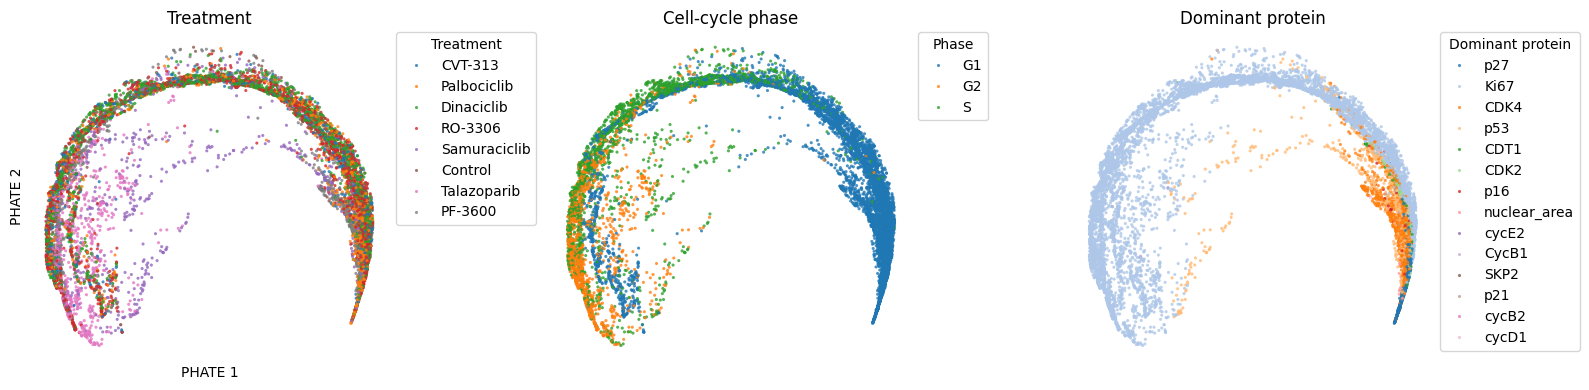

In [13]:
# Set up visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes = axes.flatten()
sns.despine(top=True, right=True, left=True, bottom=True)

dot_size = 5


# Treatment
sns.scatterplot(
    data=phate_df, x="PHATE 1", y="PHATE 2", hue="treatment",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Treatment")
axes[0].legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Cell-cycle phase
sns.scatterplot(
    data=phate_df, x="PHATE 1", y="PHATE 2", hue="phase",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Cell-cycle phase")
axes[1].legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Dominant protein per sample
sns.scatterplot(
    data=phate_df, x="PHATE 1", y="PHATE 2", hue="dominant_protein",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[2], palette="tab20"
)
axes[2].set_title("Dominant protein")
axes[2].legend(
    title="Dominant protein", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)

# axes[2].get_legend().remove()  # Optionally remove dominant protein legend if too long


# Final touches
for ax in axes:
    if ax == axes[0]: 
        ax.set_xlabel("PHATE 1")
        ax.set_ylabel("PHATE 2")
    else: 
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

PHATE embeds each cell into two dimensions that preserve the manifold structure of the raw z-scored protein measurements, so nearby points have similar protein profiles. Treatment shows how strongly each drug separates cells in protein space; cell-cycle phase shows the variation across G1 to S to G2 progression; dominant protein labels each cell by its highest-reading marker.

---

## 2. Data analysis:

We model our tensor via: $\textit{treatment} \times \textit{cell-cycle phase} \times \textit{protein}$. Let $t \in \mathbb{N}$ be the number of treatments, in our case $t = 8$, let $c \in \mathbb{N}$ the number of cell-cycle phases, here $c = 3$, and let $p \in \mathbb{N}$ be the number of proteins analyzed, here $p = 22$. After performing a Tucker decomposition on said tensor, we may obtain: 

$$
\begin{split}
X & \approx \mathcal{G} \times_1 T \times_2 C \times_3 P \\
        & = (\mathcal{G} \times_1 T \times_2 C) \times_3 P \\
        & = \mathcal{F} \times_3 P  
\end{split}
$$

where $T \in \mathbb{R}^{t_F \times t}$ are the treatment loadings, $C \in \mathbb{R}^{c_F \times c}$ are the cell-cycle-phase loadings, $P \in \mathbb{R}^{p_F \times p}$ are the protein loadings, and $\mathcal{F} \in \mathbb{R}^{t \times c \times p_F}$ is a tensor encoding the effect of the treatments on the protein-factors across cell-cycles. (Note that $t_F$, $c_F$, and $p_F$ denote the treatment-facotrs, cell-cycle-phase-factors, and protein-factors, respectively.)

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each $\texttt{(treatment, cell-cycle-phase)}$ and obtaining our tensor by stacking across proteins.

In [14]:
def pseudobulk(adata):
    # Convert AnnData to DataFrame 
    adata_df = adata.to_df()
    
    # Group by drug_name and GMM_phase_labels, then get mean of each group
    pseudobulk_df = adata_df.groupby([adata.obs["drug_name"], adata.obs["GMM_phase_labels"]], observed=True).mean()
    
    # z-scale 
    pseudobulk_df_scales = (pseudobulk_df - pseudobulk_df.mean()) / pseudobulk_df.std()
    
    # Reshape to (n_treatments, n_phases, n_proteins)
    return_tensor = pseudobulk_df_scales.values.reshape(len(adata.obs["drug_name"].cat.categories), len(adata.obs["GMM_phase_labels"].cat.categories), -1)
    return return_tensor

In [15]:
pseudobulk_tensor = pseudobulk(adata)
print(f'Pseudobulk tensor shape: {pseudobulk_tensor.shape}')

print("Example pseudobulk values for the first protein:")
pd.DataFrame(pseudobulk_tensor[:, :, 0], index=adata.obs["drug_name"].cat.categories, columns=adata.obs["GMM_phase_labels"].cat.categories)

Pseudobulk tensor shape: (8, 3, 22)
Example pseudobulk values for the first protein:


,G1,G2,S
CVT-313,-1.273687,1.076559,-0.135403
Control,-1.274309,1.482185,0.101079
Dinaciclib,-1.006185,0.910127,-0.210214
PF-3600,-1.570209,0.924591,0.267661
Palbociclib,-1.408130,0.978855,-0.156857
RO-3306,-1.161159,1.305416,-0.082667
Samuraciclib,-1.481422,0.582920,0.301016
Talazoparib,-0.329189,1.121702,1.037320


In [16]:
def HOSVD(tensor, truncation_rank=None):
    dims = tensor.shape
    
    if truncation_rank is None:
        truncation_rank = dims
    
    factors = []
    for i, _ in enumerate(dims): 
        matrix = tl.unfold(tensor, mode=i)
        
        rank = np.linalg.matrix_rank(matrix)
        factor = np.linalg.svd(matrix, full_matrices=False)[0][:, :rank]
        
        factors.append(factor[:, :truncation_rank[i]])
    
    factors_transposed = [f.T for f in factors]
    
    core = tenalg.multi_mode_dot(tensor, factors_transposed)
        
    return core, factors

### 2.2 Protein Rank-Selection:

We consider first the protein rank. To do so, we compute Tucker decompositions of our tensor, keeping the ranks of the other axes fixed at the maximum. 

In [17]:
err_dict = {}

for i in range(len(proteins)):
    truncation_rank = [pseudobulk_tensor.shape[0], pseudobulk_tensor.shape[1], i+1]
    core, factors = HOSVD(pseudobulk_tensor, truncation_rank=truncation_rank)
    
    recon = tenalg.multi_mode_dot(core, factors)
    err = np.linalg.norm(recon - pseudobulk_tensor) / np.linalg.norm(pseudobulk_tensor)
    
    err_dict[i+1] = err

We interpolate the first an the last value and compute the difference between the reconstruction loss and the interpolation line. The value to be chosen is that which maximizes the difference. 

In [18]:
start_err = err_dict[1]
end_err = err_dict[len(err_dict)]
steps = len(err_dict)

interpol_line = {i: (start_err * (((steps-1) - (i-1))/(steps-1)) + end_err * ((i-1)/(steps-1))) for i in range(1, steps+1)}
diff = {i: interpol_line[i] - err_dict[i] for i in range(1, steps+1)}

n_protein_factors = max(diff, key=diff.get)
print(f"Maximum difference at step {n_protein_factors}: {diff[n_protein_factors]}")

Maximum difference at step 8: 0.3001968285629225


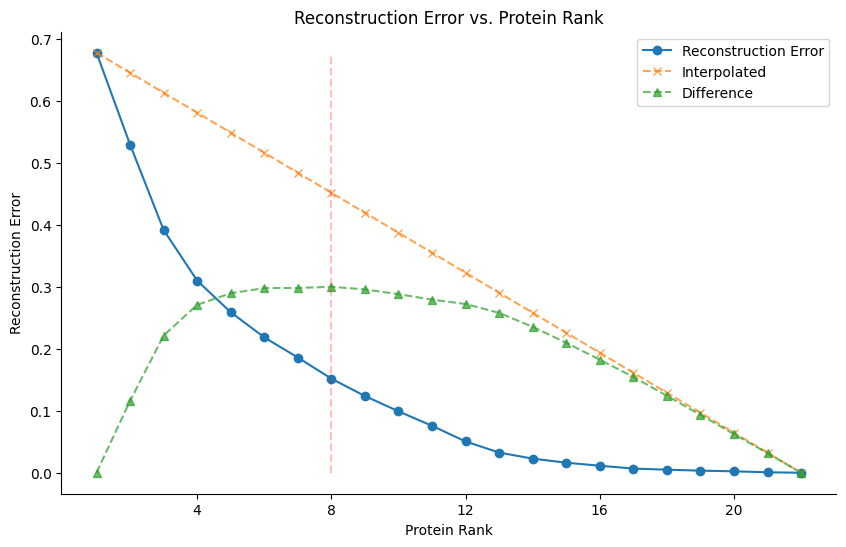

In [19]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)

ax.set_ylabel("Reconstruction Error")
ax.set_xlabel("Protein Rank")
ax.set_xticks([k for k in err_dict if k % 4 == 0])

ax.spines[["top", "right"]].set_visible(False)

ax.plot(list(err_dict.keys()), list(err_dict.values()), marker='o')
ax.plot(list(interpol_line.keys()), list(interpol_line.values()), alpha=0.7, marker='x', linestyle='--')
ax.plot(list(diff.keys()), list(diff.values()), alpha=0.7, marker='^', linestyle='--')
ax.vlines(n_protein_factors, 0, err_dict[1], colors='red', alpha=0.25, linestyle='--')

plt.legend(["Reconstruction Error", "Interpolated", "Difference"])
plt.title("Reconstruction Error vs. Protein Rank")
plt.show()

In [40]:
n_protein_factors = 4

In [41]:
truncation_rank = [pseudobulk_tensor.shape[0], pseudobulk_tensor.shape[1], n_protein_factors]
core, factors = HOSVD(pseudobulk_tensor, truncation_rank=truncation_rank)

treatment_loadings = factors[0]
cell_phase_loadings = factors[1]
protein_loadings = factors[2]

---

## 3. Visualizations:

### 3.1 Latent Protein-Factors over Tensor Components:

In [42]:
from numpy import matrix


def matrix_heatmap(matrix, xticks=None, yticks=None, xlabel=None, ylabel=None, title=None, x_tick_size=8, y_tick_size=8, text_size=8):
    fig = plt.figure(figsize=(16, 14))
    ax = fig.add_subplot(1, 1, 1)

    vmax = np.abs(matrix).max() or 1.0

    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

    if xticks is not None:
        ax.set_xticks(np.arange(len(xticks)))
        ax.set_xticklabels(xticks, fontsize=x_tick_size)
    else:
        ax.set_xticks(np.arange(matrix.shape[1]))
        ax.set_xticklabels(np.arange(1, matrix.shape[1] + 1))

    if yticks is not None:
        ax.set_yticks(np.arange(len(yticks)))
        ax.set_yticklabels(yticks, fontsize=y_tick_size)
    else: 
        ax.set_yticks(np.arange(matrix.shape[0]))
        ax.set_yticklabels(np.arange(1, matrix.shape[0] + 1))
    
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=text_size,
                color="white" if abs(matrix[i, j]) > 0.6 * vmax else "black"
            )
                
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.4, pad=0.05)

    if title:
        plt.title(title, fontsize=13)
        
    plt.show()

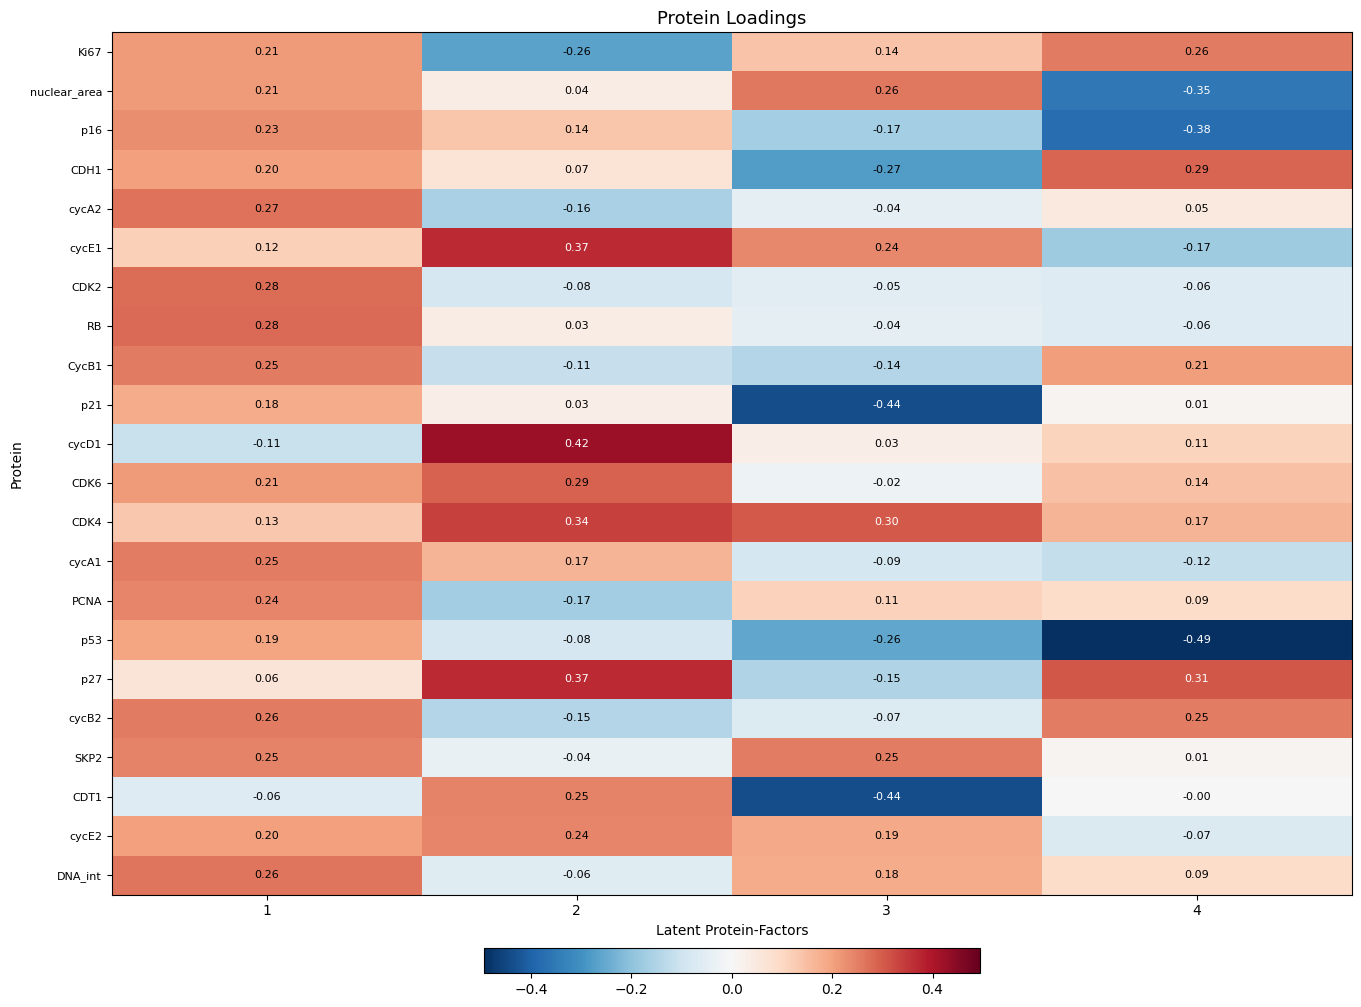

In [43]:
matrix_heatmap(
    protein_loadings, 
    yticks=proteins,
    xlabel="Latent Protein-Factors", ylabel="Protein", 
    title="Protein Loadings", 
    y_tick_size=8, text_size=8
)

Each column is one latent protein-factor, an orthonormal direction in protein space; each row is a protein's weight on those directions. Values are to be interpreted contrastively; proteins with the same sign on a factor co-vary along it, opposite signs move in opposition. (Note that the overall sign of a column is arbitrary, since flipping a factor and its matching scores leaves the reconstruction unchanged.) 

Because the pseudobulk is z-scored, the overall intensity doesn't influence the individual loadings. Values capture contrast between proteins. 

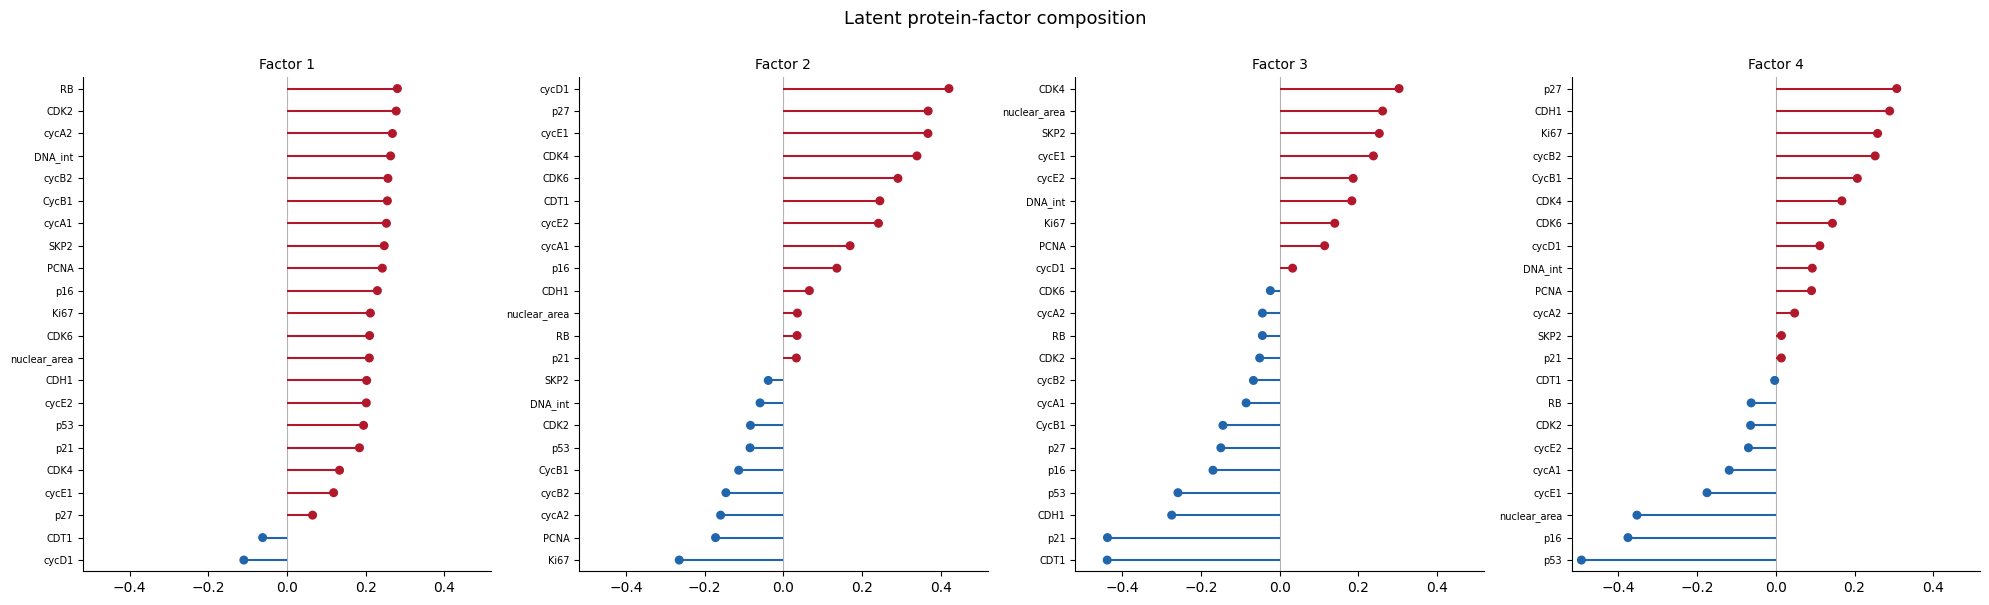

In [48]:
POS, NEG = "#b2182b", "#2166ac" 

n = protein_loadings.shape[1]
vmax = np.abs(protein_loadings).max() or 1.0
proteins = np.asarray(proteins)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.flatten()
for k, ax in enumerate(axes):
    if k >= n:
        ax.axis("off")
        continue
    order = np.argsort(protein_loadings[:, k])  # negatives bottom, positives top
    vals = protein_loadings[order, k]
    y = np.arange(len(vals))
    colors = np.where(vals >= 0, POS, NEG)

    ax.hlines(y, 0, vals, color=colors, lw=1.5)
    ax.scatter(vals, y, color=colors, s=30, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(proteins[order], fontsize=7)
    ax.set_ylim(-0.5, len(vals) - 0.5)
    ax.set_xlim(-1.05 * vmax, 1.05 * vmax)
    ax.axvline(0, color="0.7", lw=0.8, zorder=0)
    ax.set_title(f"Factor {k + 1}", fontsize=10)

sns.despine(fig=fig)
fig.suptitle(f"Latent protein-factor composition", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

We now also consider the tensor $\mathcal{F} = \mathcal{G} \times_1 T \times_2 C \in \mathbb{R}^{t \times c \times p_F}$. We may obtain matrices $\mathbf{F}^{(T)} \in \mathbb{R}^{p_F \times t}$, and $\mathbf{F}^{(C)} \in \mathbb{R}^{p_F \times c}$ by averaging over the remaining dimension. 

In [49]:
F = tenalg.multi_mode_dot(
    core,
    [treatment_loadings, cell_phase_loadings],
    modes=[0, 1],
)

**Latent Protein-Factors by treatment:**

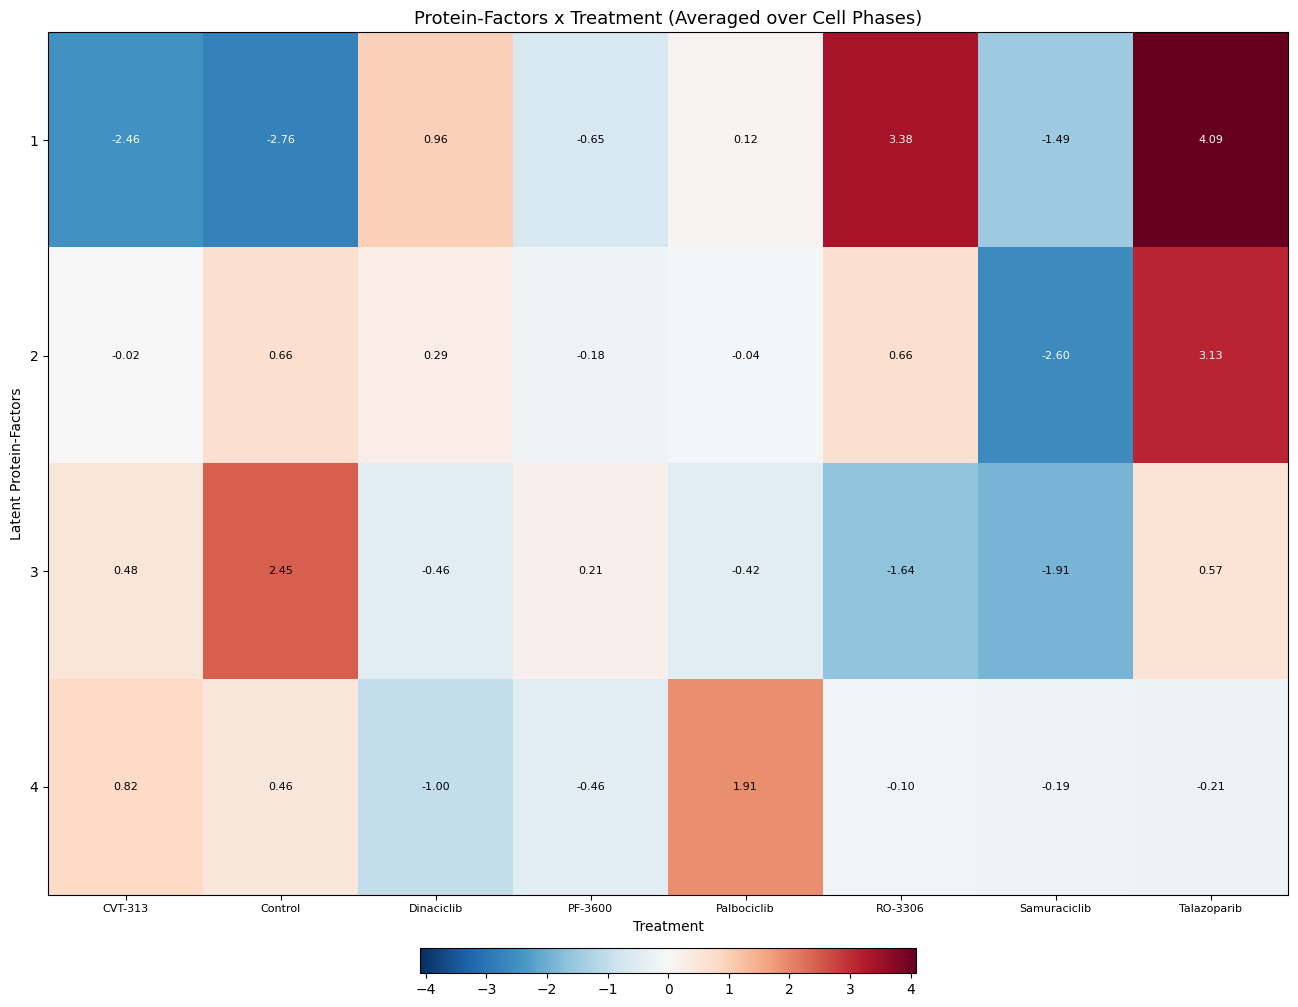

In [50]:
proteins_treatment_loadings = F.mean(axis=1).T  # average over: (1) cell-cycle phases
proteins_treatment = proteins_treatment_loadings @ treatment_loadings.T

matrix_heatmap(
    proteins_treatment, 
    xticks=treatments,
    xlabel="Treatment", ylabel="Latent Protein-Factors", 
    title="Protein-Factors x Treatment (Averaged over Cell Phases)"
)

F averaged over cell-cycle phase, then mapped back onto the treatments through the treatment loadings, giving each latent protein-factor's average level per drug. A positive entry means that drug pushes the factor in its positive direction relative to other treatments; one would have to combine the sign here with the protein loadings to see which proteins rise or fall. Columns that look alike flag drugs with similar multiprotein effects.

**Latent Protein-Factors by cell-cycle phase:**

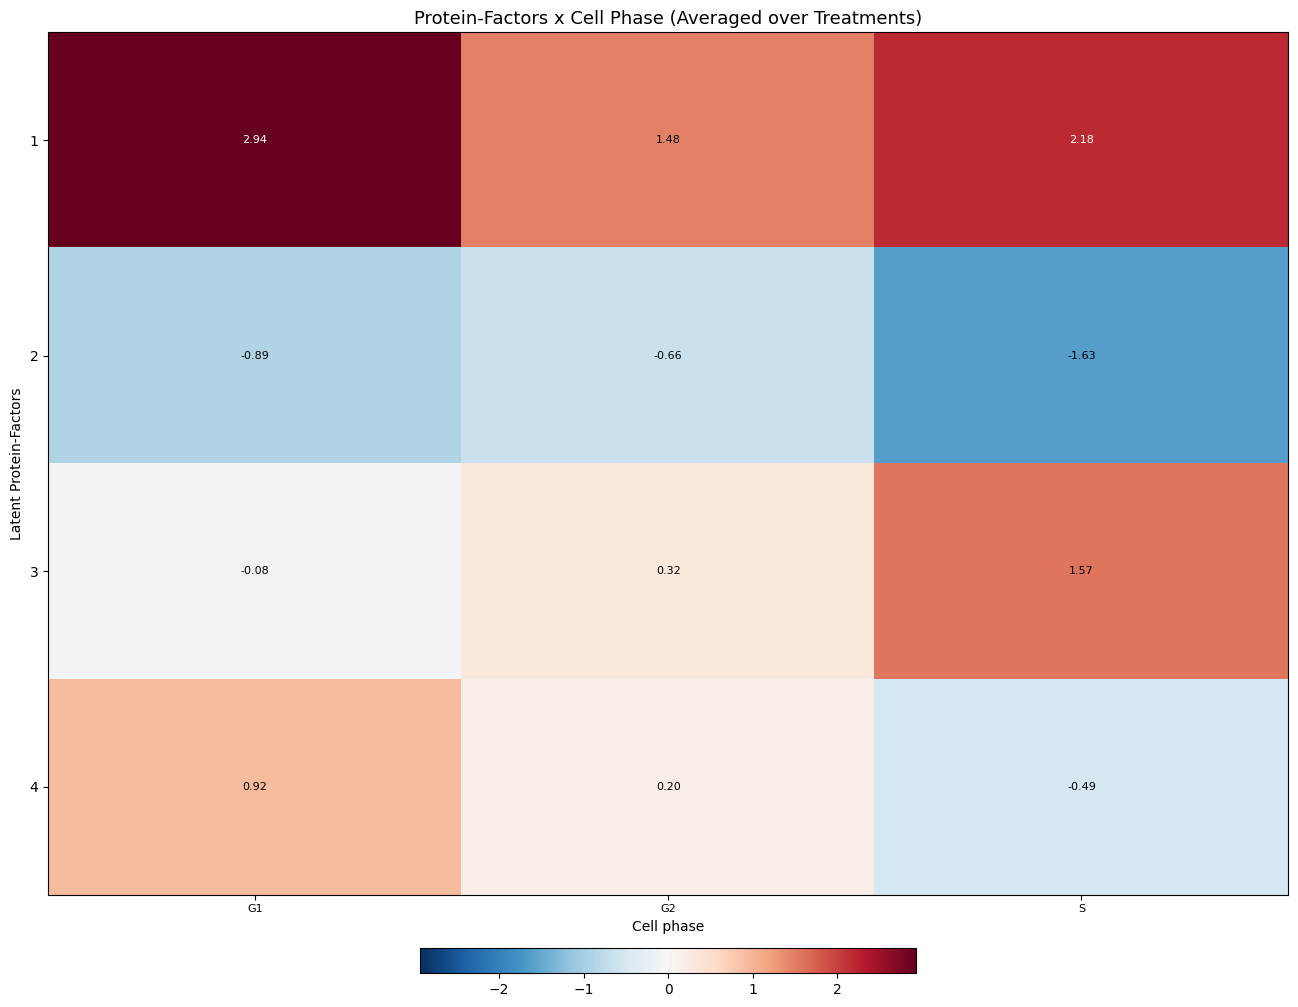

In [51]:
proteins_phase_loadings = F.mean(axis=0).T  # average over: (0) treatments
proteins_phase = proteins_phase_loadings @ cell_phase_loadings.T

matrix_heatmap(
    proteins_phase, 
    xticks=phases, 
    xlabel="Cell phase", ylabel="Latent Protein-Factors", 
    title="Protein-Factors x Cell Phase (Averaged over Treatments)"
)

Same construction averaged over treatments, showing how each latent protein-factor varies across G1, S, and G2. This shows how cell-cycle influences each multiprotein factor; a factor whose sign flips across phases encodes a phase-specific program. 

### 3.2 Tensor Slices for Different Cell-Lines:

In [52]:
F.shape

(8, 3, 4)

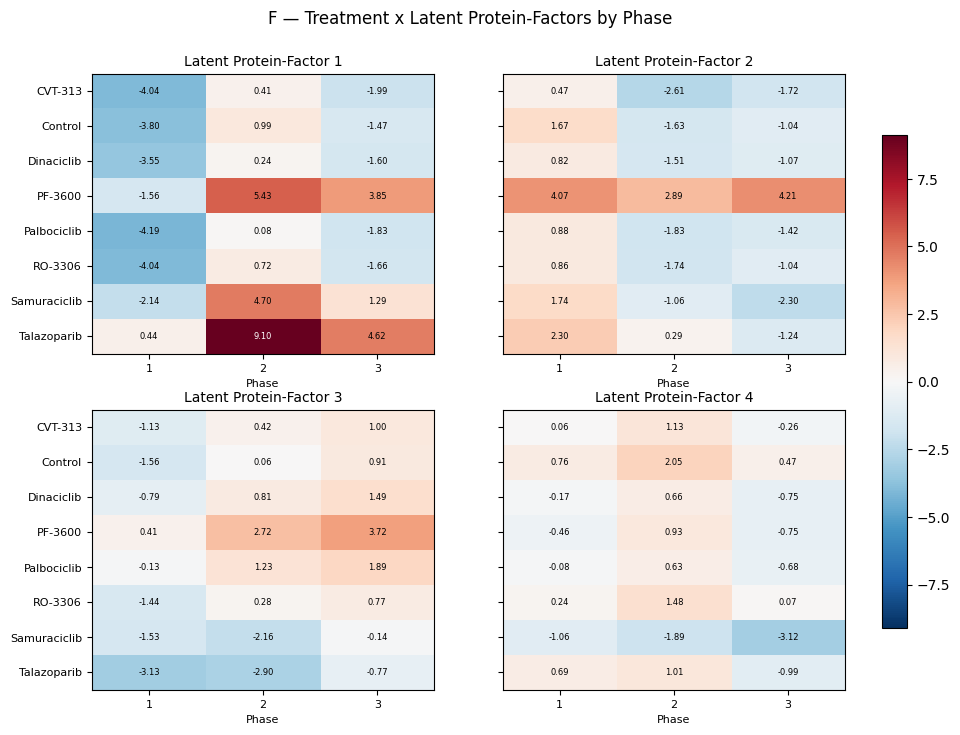

In [56]:
def slice_montage(F, treatments, phases, annotate=True):
    n_treatments = F.shape[0]
    n_phases = F.shape[1]
    n_factors = F.shape[2]
    vmax = np.abs(F).max() or 1.0   # shared scale across all phases

    fig, axes = plt.subplots(
        2, int(n_factors/2), figsize=(3 * n_factors, 8), squeeze=False
    )
    axes = axes.ravel()

    for f in range(n_factors):
        ax = axes[f]
        
        im = ax.imshow(
            F[:, :, f], cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto"
        )
        
        ax.set_title(f"Latent Protein-Factor {f+1}", fontsize=10)
        ax.set_xticks(np.arange(n_phases))
        ax.set_xticklabels(np.arange(1, n_phases + 1), fontsize=8)
        ax.set_xlabel("Phase", fontsize=8)
        ax.set_yticks(np.arange(len(treatments)))
        ax.set_yticklabels(treatments if f == 0 or f == 2 else [], fontsize=8)

        if annotate:
            for i in range(n_treatments):
                for j in range(n_phases):
                    v = F[i, j, f]
                    ax.text(
                        j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if abs(v) > 0.6 * vmax else "black",
                    )

    fig.suptitle("F — Treatment x Latent Protein-Factors by Phase", position=(0.44, 0.96))
    fig.colorbar(im, ax=axes.tolist(), orientation="vertical", shrink=0.8, pad=0.04)
    plt.show()
    
slice_montage(F, treatments, phases, annotate=True)

Each panel is one cell-cycle phase slice of F (slices are: $\textit{treatment} \times \textit{latent protein-factor}$). Reading a single treatment's row across the panels shows how its factor profile changes with phase; reading down a column compares treatments within one phase. This shows the actual values of $F$ before the averaged treatment heatmaps above.

---

## 4. Understanding Latent Protein-Factors:

### 4.1 PHATE colored by Latent Protein-Factors:

We may project our original data matrix $\mathbf{X} \in \mathbb{R}^{(n \times p)}$ into the latent protein-factor space by: $\mathbf{X} \cdot \mathbf{P} \in \mathbb{R}^{n \times p_F}$, where $\mathbf{P} \in \mathbb{R}^{p \times p_F}$ are our protein-factor loadings. 

In [57]:
X_full = np.asarray(adata.X)
mu = X_full.mean(0)
sd = np.where(X_full.std(0) == 0, 1.0, X_full.std(0))

def embed_factors(X):
    """Z-score X against the global (mu, sd) and project onto protein_loadings."""
    Xz = (np.asarray(X) - mu) / sd
    return Xz, Xz @ protein_loadings

factor_names = [f"Factor {i + 1}" for i in range(protein_loadings.shape[1])]

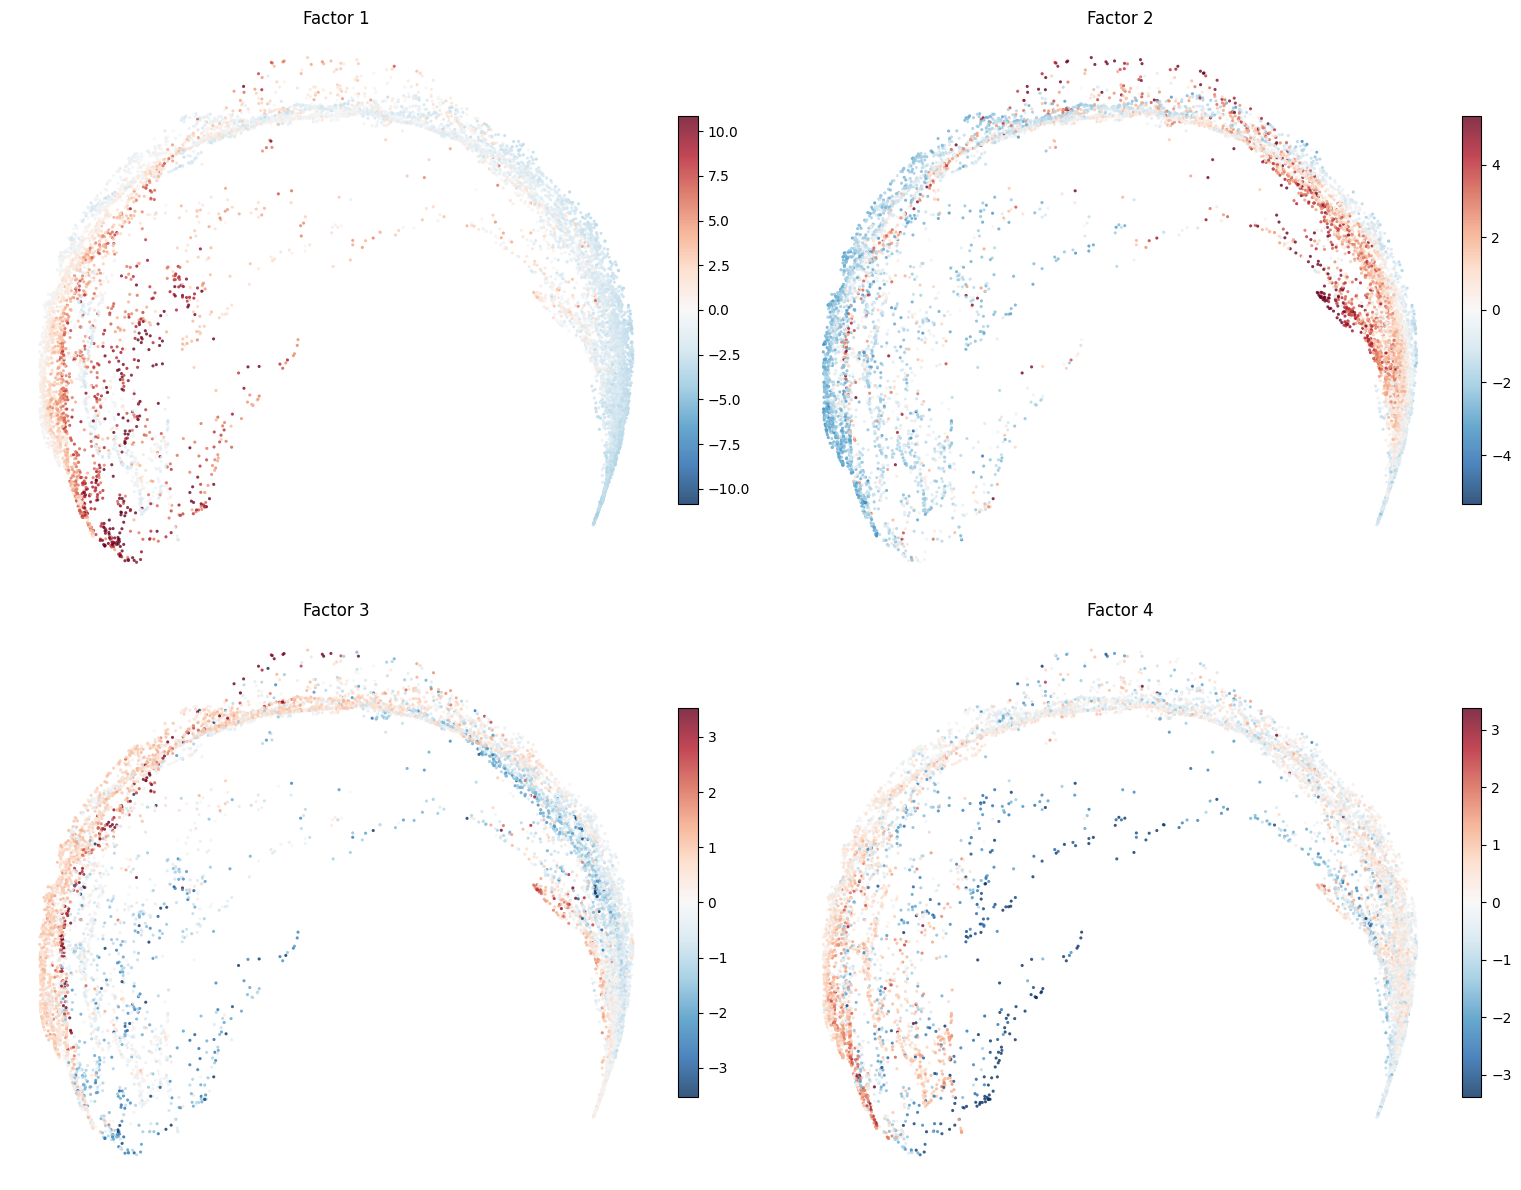

In [59]:
_, embed = embed_factors(adata_sub.X)
embed = pd.DataFrame(embed, columns=factor_names)
n_factors = embed.shape[1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
sns.despine(top=True, right=True, left=True, bottom=True)

for k, ax in enumerate(axes):
    if k >= n_factors:
        ax.axis("off")
        continue

    c = embed.iloc[:, k]
    vmax = np.nanpercentile(np.abs(c), 99) or 1.0

    pts = ax.scatter(
        data_phate[:, 0], data_phate[:, 1], c=c, cmap="RdBu_r",
        vmin=-vmax, vmax=vmax, s=dot_size, linewidth=0, alpha=0.8,
    )

    ax.set_title(factor_names[k])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(pts, ax=ax, shrink=0.7, pad=0.02)

plt.tight_layout()
plt.show()

### 4.2 Archetypal Cells:

In [60]:
n_per = 3000
per_treatment = {}
for t in treatments:
    sub = sc.pp.subsample(
        adata[adata.obs["drug_name"] == t],
        n_obs=min(n_per, int((adata.obs["drug_name"] == t).sum())),
        copy=True, random_state=0,
    )

    Xz, embed = embed_factors(sub.X)
    norms = np.linalg.norm(Xz, axis=1, keepdims=True)  # (n_cells, 1)

    per_treatment[t] = {
        "embed": embed,  # (n_cells, n_factors)
        "phate_coords": phate.PHATE(random_state=0, verbose=0).fit_transform(Xz),
        "cos_dist": 1 - embed / norms,  # (n_cells, n_factors)
        "phase": sub.obs["GMM_phase_labels"].astype(str).values,
    }

    SGD-MDS may not have converged: stress changed by -1.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -3.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -2.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.


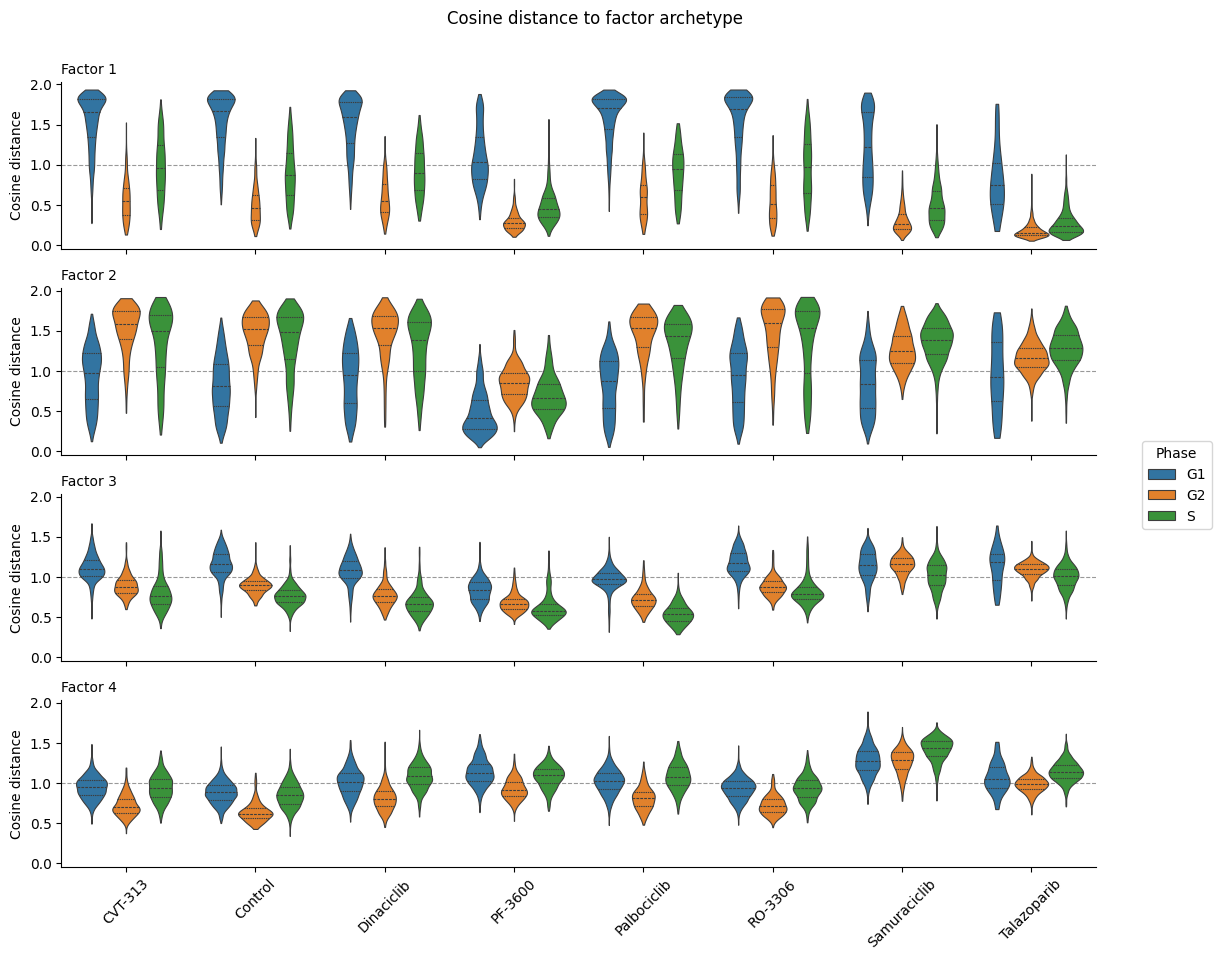

In [62]:
df = pd.concat(
    [
        pd.DataFrame({
            "treatment": t,
            "phase": per_treatment[t]["phase"],
            "factor": fname,
            "cos_dist": per_treatment[t]["cos_dist"][:, f],
        })
        for t in treatments
        for f, fname in enumerate(factor_names)
    ],
    ignore_index=True,
)

n_factors = len(factor_names)
fig, axes = plt.subplots(n_factors, 1, figsize=(12, 2.4 * n_factors), sharex=True, sharey=True)

for ax, fname in zip(axes, factor_names):
    sns.violinplot(
        data=df[df["factor"] == fname],
        x="treatment", y="cos_dist", hue="phase",
        order=treatments, hue_order=phases,
        cut=0, inner="quartile", linewidth=0.8, ax=ax,
    )
    
    ax.set_title(fname, loc="left", fontsize=10)
    ax.axhline(1.0, color="0.6", lw=0.8, ls="--", zorder=0)  # orthogonal to factor
    ax.set_xlabel("")
    ax.set_ylabel("Cosine distance")
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    sns.despine(ax=ax)

axes[-1].tick_params(axis="x", rotation=45)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Phase", bbox_to_anchor=(0.95, 0.5), loc="center left")
fig.suptitle("Cosine distance to factor archetype", y=0.995)
plt.tight_layout(rect=[0, 0, 0.93, 0.99])
plt.show()

### 4.3 Latent Protein-Factor per Treatment:

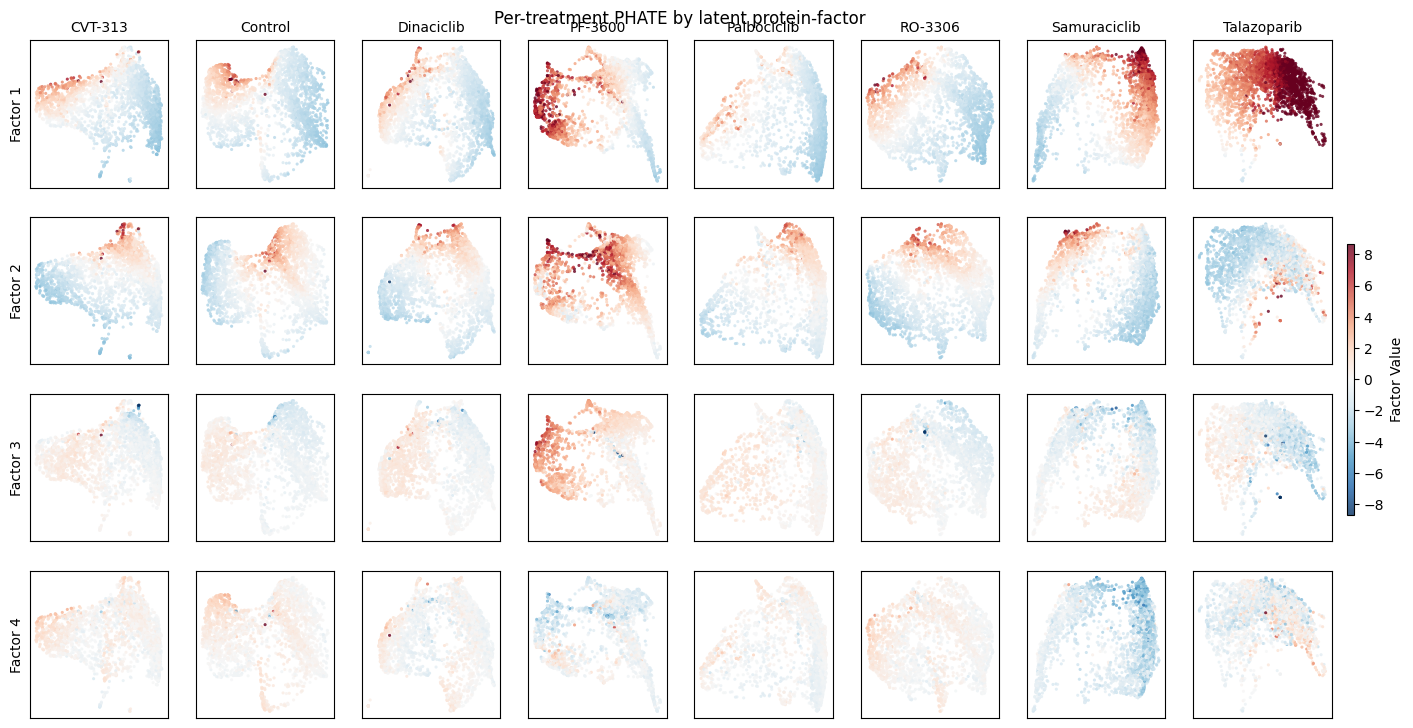

In [63]:
n_factors = len(factor_names)
all_embeds = np.concatenate([per_treatment[t]["embed"] for t in treatments], axis=0)
vmax = np.nanpercentile(np.abs(all_embeds), 99) or 1.0

fig, axes = plt.subplots(
    n_factors, len(treatments),
    figsize=(2.5 * len(treatments), 2.2 * n_factors),
    squeeze=False,
)

for f in range(n_factors):
    for a, t in enumerate(treatments):
        ax = axes[f][a]
        coords = per_treatment[t]["phate_coords"]
        
        pts = ax.scatter(
            coords[:, 0], coords[:, 1],
            c=per_treatment[t]["embed"][:, f], cmap="RdBu_r",
            vmin=-vmax, vmax=vmax, s=dot_size, linewidth=0, alpha=0.8,
        )
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        if f == 0:
            ax.set_title(t, fontsize=10)
        if a == 0:
            ax.set_ylabel(factor_names[f], fontsize=10)

fig.colorbar(pts, ax=axes, shrink=0.4, aspect=40, pad=0.01, label="Factor Value")
fig.suptitle("Per-treatment PHATE by latent protein-factor", y=0.915, x=0.45)
plt.show()

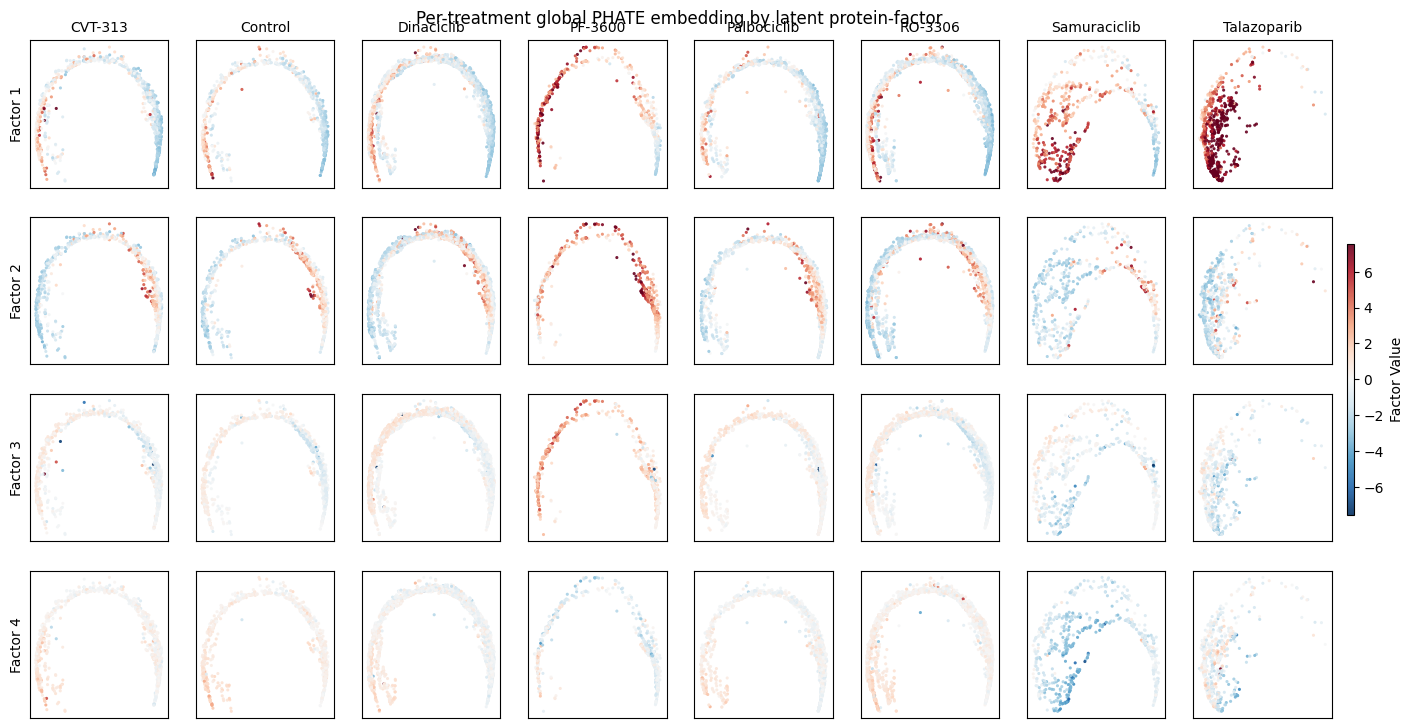

In [64]:
_, embed_global = embed_factors(adata_sub.X)
treatment_labels = adata_sub.obs["drug_name"].astype(str).values

n_factors = len(factor_names)
vmax = np.nanpercentile(np.abs(embed_global), 99) or 1.0

fig, axes = plt.subplots(
    n_factors, len(treatments),
    figsize=(2.5 * len(treatments), 2.2 * n_factors),
    squeeze=False,
)

for f in range(n_factors):
    for a, t in enumerate(treatments):
        ax = axes[f][a]
        mask = treatment_labels == t
        
        pts = ax.scatter(
            data_phate[mask, 0], data_phate[mask, 1],
            c=embed_global[mask, f], cmap="RdBu_r",
            vmin=-vmax, vmax=vmax, s=dot_size, linewidth=0, alpha=0.9,
        )

        ax.set_xticks([])
        ax.set_yticks([])
        if f == 0:
            ax.set_title(t, fontsize=10)
        if a == 0:
            ax.set_ylabel(factor_names[f], fontsize=10)

fig.colorbar(pts, ax=axes, shrink=0.4, aspect=40, pad=0.01, label="Factor Value")
fig.suptitle("Per-treatment global PHATE embedding by latent protein-factor", y=0.915, x=0.45)
plt.show()

---